In [15]:
import numpy as np
import pandas as pd

import scipy.stats as sts

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# 10.1i

In [8]:
# Reference from p.13, presentation session 11
alpha = np.array([0, np.pi/2, np.pi])

p = np.array([1/3, 1/3, 1/3])

X = [np.sin(a) for a in alpha]
Y = [np.cos(a) for a in alpha]

print(X)
print(Y)

[np.float64(0.0), np.float64(1.0), np.float64(1.2246467991473532e-16)]
[np.float64(1.0), np.float64(6.123233995736766e-17), np.float64(-1.0)]


In [9]:
EXY = sum(x*y*pi for x, y, pi in zip(X, Y, p))

In [10]:
EX = sum(x*pi for x, pi in zip(X, p))
EY = sum(y*pi for y, pi in zip(Y, p))

covXY = EXY - EX * EY

print(EX)
print(EY)

0.33333333333333337
0.0


In [13]:
varX = sum((x**2)*pi for x, pi in zip(X, p)) - EX**2
varY = sum((y**2)*pi for y, pi in zip(Y, p)) - EY**2

rho = covXY / np.sqrt(varX * varY)

print(varX)
print(varY)

0.22222222222222218
0.6666666666666666


In [14]:
EXY = round(EXY, 10)
covXY = round(covXY, 10)
rho = round(rho, 10)

print("\nE(XY) =", EXY)

print("\nCov(X,Y) =", covXY)

print("\nCorrelation coefficient =", rho)


E(XY) = -0.0

Cov(X,Y) = -0.0

Correlation coefficient = -0.0


# 10.2i

In [1]:
data = pd.DataFrame({
    "JanTemp": [
        44,38,35,31,47,42,15,22,26,30,45,65,58,37,22,19,21,11,22,27,
        45,12,25,23,21,2,24,8,13,11,27,24,14,27,34,31,0,26,21,28,
        33,24,24,38,31,24,49,44,18,7,32,33,19,9,13,14
    ],

    "Lat": [
        31.2,32.9,33.6,35.4,34.3,38.4,40.7,41.7,40.5,39.7,31.0,25.0,
        26.3,33.9,43.7,42.3,39.8,41.8,38.1,39.0,30.8,44.2,39.7,42.7,
        43.1,45.9,39.3,47.1,41.9,43.5,39.8,35.1,42.6,40.8,35.9,36.4,
        47.1,39.2,42.3,35.9,45.6,40.9,40.9,33.3,36.7,35.6,29.4,30.1,
        41.1,45.0,37.0,48.1,48.1,43.4,43.3,41.2
    ]
})

data.head()

NameError: name 'pd' is not defined

In [ ]:
X = data["Lat"].to_numpy()
Y = data["JanTemp"].to_numpy()

r_obs = sts.pearsonr(X, Y)[0]

r_obs

np.float64(-0.8480352058672054)

In [ ]:
B = 10000
r_null = np.empty(B)

# Permutation test
for i in range(B):

    Y_perm = np.random.permutation(Y)

    r_null[i] = sts.pearsonr(X, Y_perm)[0]

In [ ]:
p_value = np.mean(np.abs(r_null) >= abs(r_obs))

p_value

np.float64(0.0)

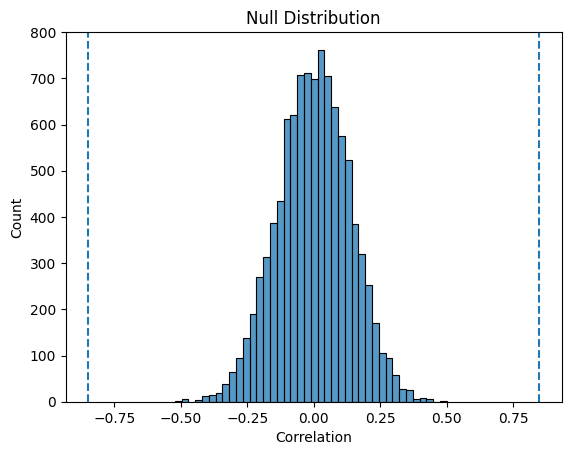

In [ ]:
sns.histplot(r_null, bins=40)

plt.axvline(r_obs, linestyle='dashed')
plt.axvline(-r_obs, linestyle='dashed')

plt.xlabel("Correlation")
plt.title("Null Distribution")

plt.show()

In [ ]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


$$
H_0:\rho = 0
$$

$$
H_1:\rho \neq 0
$$

- There is a correlation between latitude and January temperature.
- Since the p-value is \(0.0 < 0.05\), we reject \(H_0\).
- Therefore, latitude and January temperature are dependent.